# Sistema de detecção de intrusão usando uma rede multilayer Perceptron

- **A1:** [João Pedro Fernandes de Aquino](https://github.com/Joaof14)
- **A2:** [Anderson Carlos da Silva Morais](https://github.com/AndersonCSM)








## Contextualização do Projeto

A segurança de redes de computadores é um dos desafios centrais da infraestrutura digital moderna. Ataques como negação de serviço (DoS), varredura de portas (Probe) e acesso remoto não autorizado (R2L) causam prejuízos bilionários anualmente e comprometem desde sistemas corporativos até infraestruturas críticas de energia, saúde e comunicações. Sistemas de Detecção de Intrusão (IDS — Intrusion Detection Systems) são a principal linha de defesa ativa contra essas ameaças, e a automação dessa detecção por meio de aprendizado de máquina representa a fronteira atual da área.

As características de um ataque DoS se misturam às do tráfego legítimo em regiões do espaço de atributos que nenhuma linha reta consegue separar adequadamente. Assim sendo, uma rede Perceptron não é capaz de solucionar esse problema. Assim sendo, o Perceptron Multicamadas (MLP — Multilayer Perceptron), com suas camadas ocultas e funções de ativação não lineares, supera essa limitação, tornando-se uma escolha natural para este tipo de problema.


## Etapas do Projeto

1. Exploração e verificação da qualidade dos dados;
2. Validação das premissas do modelo;
3. Seleção de atributos;
4. Normalização/padronização e divisão dos dados;
5. Ajuste do modelo (treinamento);
6. Avaliação;
7. Relatório.

## Etapa 1 – Exploração e Verificação da Qualidade dos Dados

**1.1. Obter e inspecionar o dataset**

**1.2. Codificação one-hot**

**1.3. Binarização**

**1.4. Verificar a qualidade dos dados**
- **Valores ausentes:** `df.isnull().sum()` – tipicamente nenhum. Se houver, imputar ou remover.
- **Atributos constantes:** Calcular o desvio padrão; remover qualquer preditor com `std ≈ 0`.
- **Duplicatas:** `df.duplicated().sum()` e remoção, se existirem.

**1.5. Análise univariada**
- Plotar histogramas para cada um dos 34 atributos.
- Plotar boxplots para detectar outliers severos.

**1.6. Análise bivariada / multivariada**
- Matriz de correlação de Pearson e mapa de calor.
- Correlação preditor–target: gráfico de barras com interpretação do potencial discriminativo.

**1.7. Resumo**
- Resumo da qualidade (missings, constantes, outliers).
- Lista de atributos removidos (se houver).
- Matriz de correlação comentada.
- Top features discriminativas e observações para o MLP.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# sklearn e pytorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    r2_score
)
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

### 1.1. Obtain and inspect the dataset

As duas últimas colunas (attack_type e difficulty_level) se referem a saída, sendo a última descartada

In [3]:
col_names = [
"duration", "protocol_type", "service", "flag", "src_bytes",
"dst_bytes", "land", "wrong_fragment", "urgent", "hot",
"num_failed_logins", "logged_in", "num_compromised", "root_shell",
"su_attempted", "num_root", "num_file_creations", "num_shells",
"num_access_files", "num_outbound_cmds", "is_host_login",
"is_guest_login", "count", "srv_count", "serror_rate",
"srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
"diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
"dst_host_srv_count", "dst_host_same_srv_rate",
"dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
"dst_host_srv_diff_host_rate", "dst_host_serror_rate",
"dst_host_srv_serror_rate", "dst_host_rerror_rate",
"dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]

# Dados de treino: KDDTrain+.txt
data_train = pd.read_csv("data/archive/KDDTrain+.txt", sep=',', header=None, names=col_names)
data_train = data_train.drop(columns=["difficulty_level"])

# Dados de teste: KDDTest+.txt
data_test = pd.read_csv("data/archive/KDDTest+.txt", sep=',', header=None, names=col_names)
data_test = data_test.drop(columns=["difficulty_level"])

In [4]:
# Visualização do dataset
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [5]:
# informações do conjunto de treinamento
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [6]:
# informações estatística do conjunto de treinamento
# Valores categóricos (String atrapalham nessa etapa)
data_train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# informações do conjunto de teste
data_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  str    
 2   service                      22544 non-null  str    
 3   flag                         22544 non-null  str    
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell                 

In [8]:
# informações estatística do conjunto de teste
# Valores categóricos (String atrapalham nessa etapa)
data_test.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,22544.000000,2.254400e+04,2.254400e+04,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,218.859076,1.039545e+04,2.056019e+03,0.000311,0.008428,0.000710,0.105394,0.021647,0.442202,0.119899,...,193.869411,140.750532,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683
std,1407.176612,4.727864e+05,2.121930e+04,0.017619,0.142599,0.036473,0.928428,0.150328,0.496659,7.269597,...,94.035663,111.783972,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,121.000000,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000
max,57715.000000,6.282565e+07,1.345927e+06,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
# Copia dos dados para segurança nas próximas etapas
df_train = data_train.copy()
df_test = data_test.copy()

### 1.2 Codificação one-hot
Codificação one-hot paara três dados categóricos (protocol_type, service, flag)

**ONE-HOT ENCODING**

1. Converte texto em números
2. Sem criar ordem artificial entre categorias (tcp != udp)
3. Cada categoria independente
4. O modelo consegue desligar uma categoria quando ela não apareca (se for tcp, as colunas udp e icmp = 0)

DADOS ORIGINAIS (categorias como texto):
- protocol_type: tcp
- service: ftp_data
- flag: SF

APÓS ONE-HOT ENCODING (valores binários):

**RESUMO DO ENCODING:**
- Valores: APENAS 0 e 1
- Por linha: EXATAMENTE 1 em cada categoria
- Total: 42 colunas originais → 123 colunas finais (+81 codificadas)

**Exemplo:**

Converte 1 coluna categórica em 3 colunas binárias:

Original: protocol_type = "tcp"

Após one-hot:
- protocol_type_tcp:  1 X
- protocol_type_udp:  0
- protocol_type_icmp: 0

Original: protocol_type = "udp"

Após one-hot:
- protocol_type_tcp:  0
- protocol_type_udp:  1 X
- protocol_type_icmp: 0

**O problema:**
Treino e Teste têm 123 colunas iguais, mas têm valores diferentes dentro delas.

- No treino apareceram 70 tipos de serviço diferentes
- No teste apareceram apenas 64 tipos, **6 serviços do treino não existem no teste (harvest, http_2784, aol, etc)**

Isso significa que no teste, essas 6 colunas são sempre zero
Nenhuma conexão usa esses serviços no teste
É como se no teste nunca houve ataque/conexão daquele tipo

VALIDAR BALANCEAMENTO DE NORMAL VS ATAQUE
Para usar: y_binary = y_binary_1


In [10]:
# One-hot encode para: protocol_type, service e flag

# IMPORTANTE: Fazer get_dummies no treino primeiro, depois alinhar o teste
df_train_encoded = pd.get_dummies(df_train, columns=['protocol_type', 'service', 'flag'], dtype=int)
df_test_encoded = pd.get_dummies(df_test, columns=['protocol_type', 'service', 'flag'], dtype=int)

# Alinhar as colunas do teste com o treino (adicionar colunas faltantes com 0)
df_test_encoded = df_test_encoded.reindex(columns=df_train_encoded.columns, fill_value=0)

In [11]:
df_train_encoded.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,146,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,232,8153,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,0,199,420,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


### 1.3 Binarização de rótulo

Binarização de rótulo:
- 0 - Será Tráfego normal
- 1 - Qualquer tipo de ataque



In [12]:
# BINARIZAÇÃO DO TARGET
# compara cada valor com normale faz o cast para int: False = 0 e True = 1
target_binary = (df_train_encoded['attack_type'] != 'normal').astype(int) # diferente de normal então é um ataque
target_test_binary = (df_test_encoded['attack_type'] != 'normal').astype(int)

In [13]:
print("Distribuição TREINO:")
print(f"  Normal: {(target_binary == 0).sum()} amostras")
print(f"  Ataque: {(target_binary == 1).sum()} amostras")

print(f"\n Distribuição TESTE:")
print(f"  Normal: {(target_test_binary  == 0).sum()} amostras")
print(f"  Ataque: {(target_test_binary  == 1).sum()} amostras")

Distribuição TREINO:
  Normal: 67343 amostras
  Ataque: 58630 amostras

 Distribuição TESTE:
  Normal: 9711 amostras
  Ataque: 12833 amostras


### 1.4 Verificar a Qualidade dos dados / Data quality checks

- Conforme inspeção inicial o conjunto de dado não apresenta valores nulos, ausentes ou que exigem tratamento específico.

#### 1.4.1 Valores ausentes, atributos constantes e duplicatas


In [14]:
numeric_cols = df_train.select_dtypes(include='number').columns.tolist()

# --- 1.4.1  Valores ausentes ---
missing = df_train.isnull().sum()
print(' Valores ausentes por coluna (top‑10):')
print(missing[missing > 0].sort_values(ascending=False).head(10))
if missing.sum() == 0:
    print('  Nenhum valor ausente encontrado.\n')

# --- 1.4.2  Atributos constantes (std ≈ 0) ---
stds = df_train[numeric_cols].std()
const_cols = stds[stds < 1e-6].index.tolist()
print(f' Atributos constantes quasi‑constantes (std < 1e‑6): {const_cols if const_cols else "Nenhum"}')
print(f'  Candidatos a remoção: {len(const_cols)} feature(s)\n')

# --- 1.4.3  Duplicatas ---
n_dup = df_train.duplicated().sum()
print(f' Linhas duplicadas: {n_dup} ({100*n_dup/len(df_train):.2f}%)')

 Valores ausentes por coluna (top‑10):
Series([], dtype: int64)
  Nenhum valor ausente encontrado.

 Atributos constantes quasi‑constantes (std < 1e‑6): ['num_outbound_cmds']
  Candidatos a remoção: 1 feature(s)

 Linhas duplicadas: 0 (0.00%)


### 1.5 Análise univariada / Univariate analysis

#### Estatísticas descritivas dos 38 atributos numéricos

Tabela com média, mediana, desvio padrão, mínimo e máximo para cada feature numérica.
Features com escalas muito diferentes indicam necessidade de normalização.


In [15]:
# Estatísticas descritivas completas
desc = df_train[numeric_cols].describe().T
desc['median'] = df_train[numeric_cols].median()
desc['skew']   = df_train[numeric_cols].skew()
desc = desc[['count','mean','median','std','min','25%','75%','max','skew']]
desc.round(3)

,count,mean,median,std,min,25%,75%,max,skew
duration,125973.0,287.145,0.00,2604.515,0.0,0.00,0.00,4.290800e+04,11.880
src_bytes,125973.0,45566.743,44.00,5870331.182,0.0,0.00,276.00,1.379964e+09,190.669
dst_bytes,125973.0,19779.114,0.00,4021269.151,0.0,0.00,516.00,1.309937e+09,290.053
land,125973.0,0.000,0.00,0.014,0.0,0.00,0.00,1.000000e+00,70.965
wrong_fragment,125973.0,0.023,0.00,0.254,0.0,0.00,0.00,3.000000e+00,11.458
urgent,125973.0,0.000,0.00,0.014,0.0,0.00,0.00,3.000000e+00,149.915
hot,125973.0,0.204,0.00,2.150,0.0,0.00,0.00,7.700000e+01,12.590
num_failed_logins,125973.0,0.001,0.00,0.045,0.0,0.00,0.00,5.000000e+00,53.764
logged_in,125973.0,0.396,0.00,0.489,0.0,0.00,1.00,1.000000e+00,0.426
num_compromised,125973.0,0.279,0.00,23.942,0.0,0.00,0.00,7.479000e+03,250.108


#### Histogramas – distribuição de cada feature numérica

Permite identificar:
- Distribuições **assimétricas** → podem precisar de transformação log
- Distribuições **bimodais/multimodais** → indicam classes separáveis
- Features com **variância ≈ 0** → candidatas a remoção


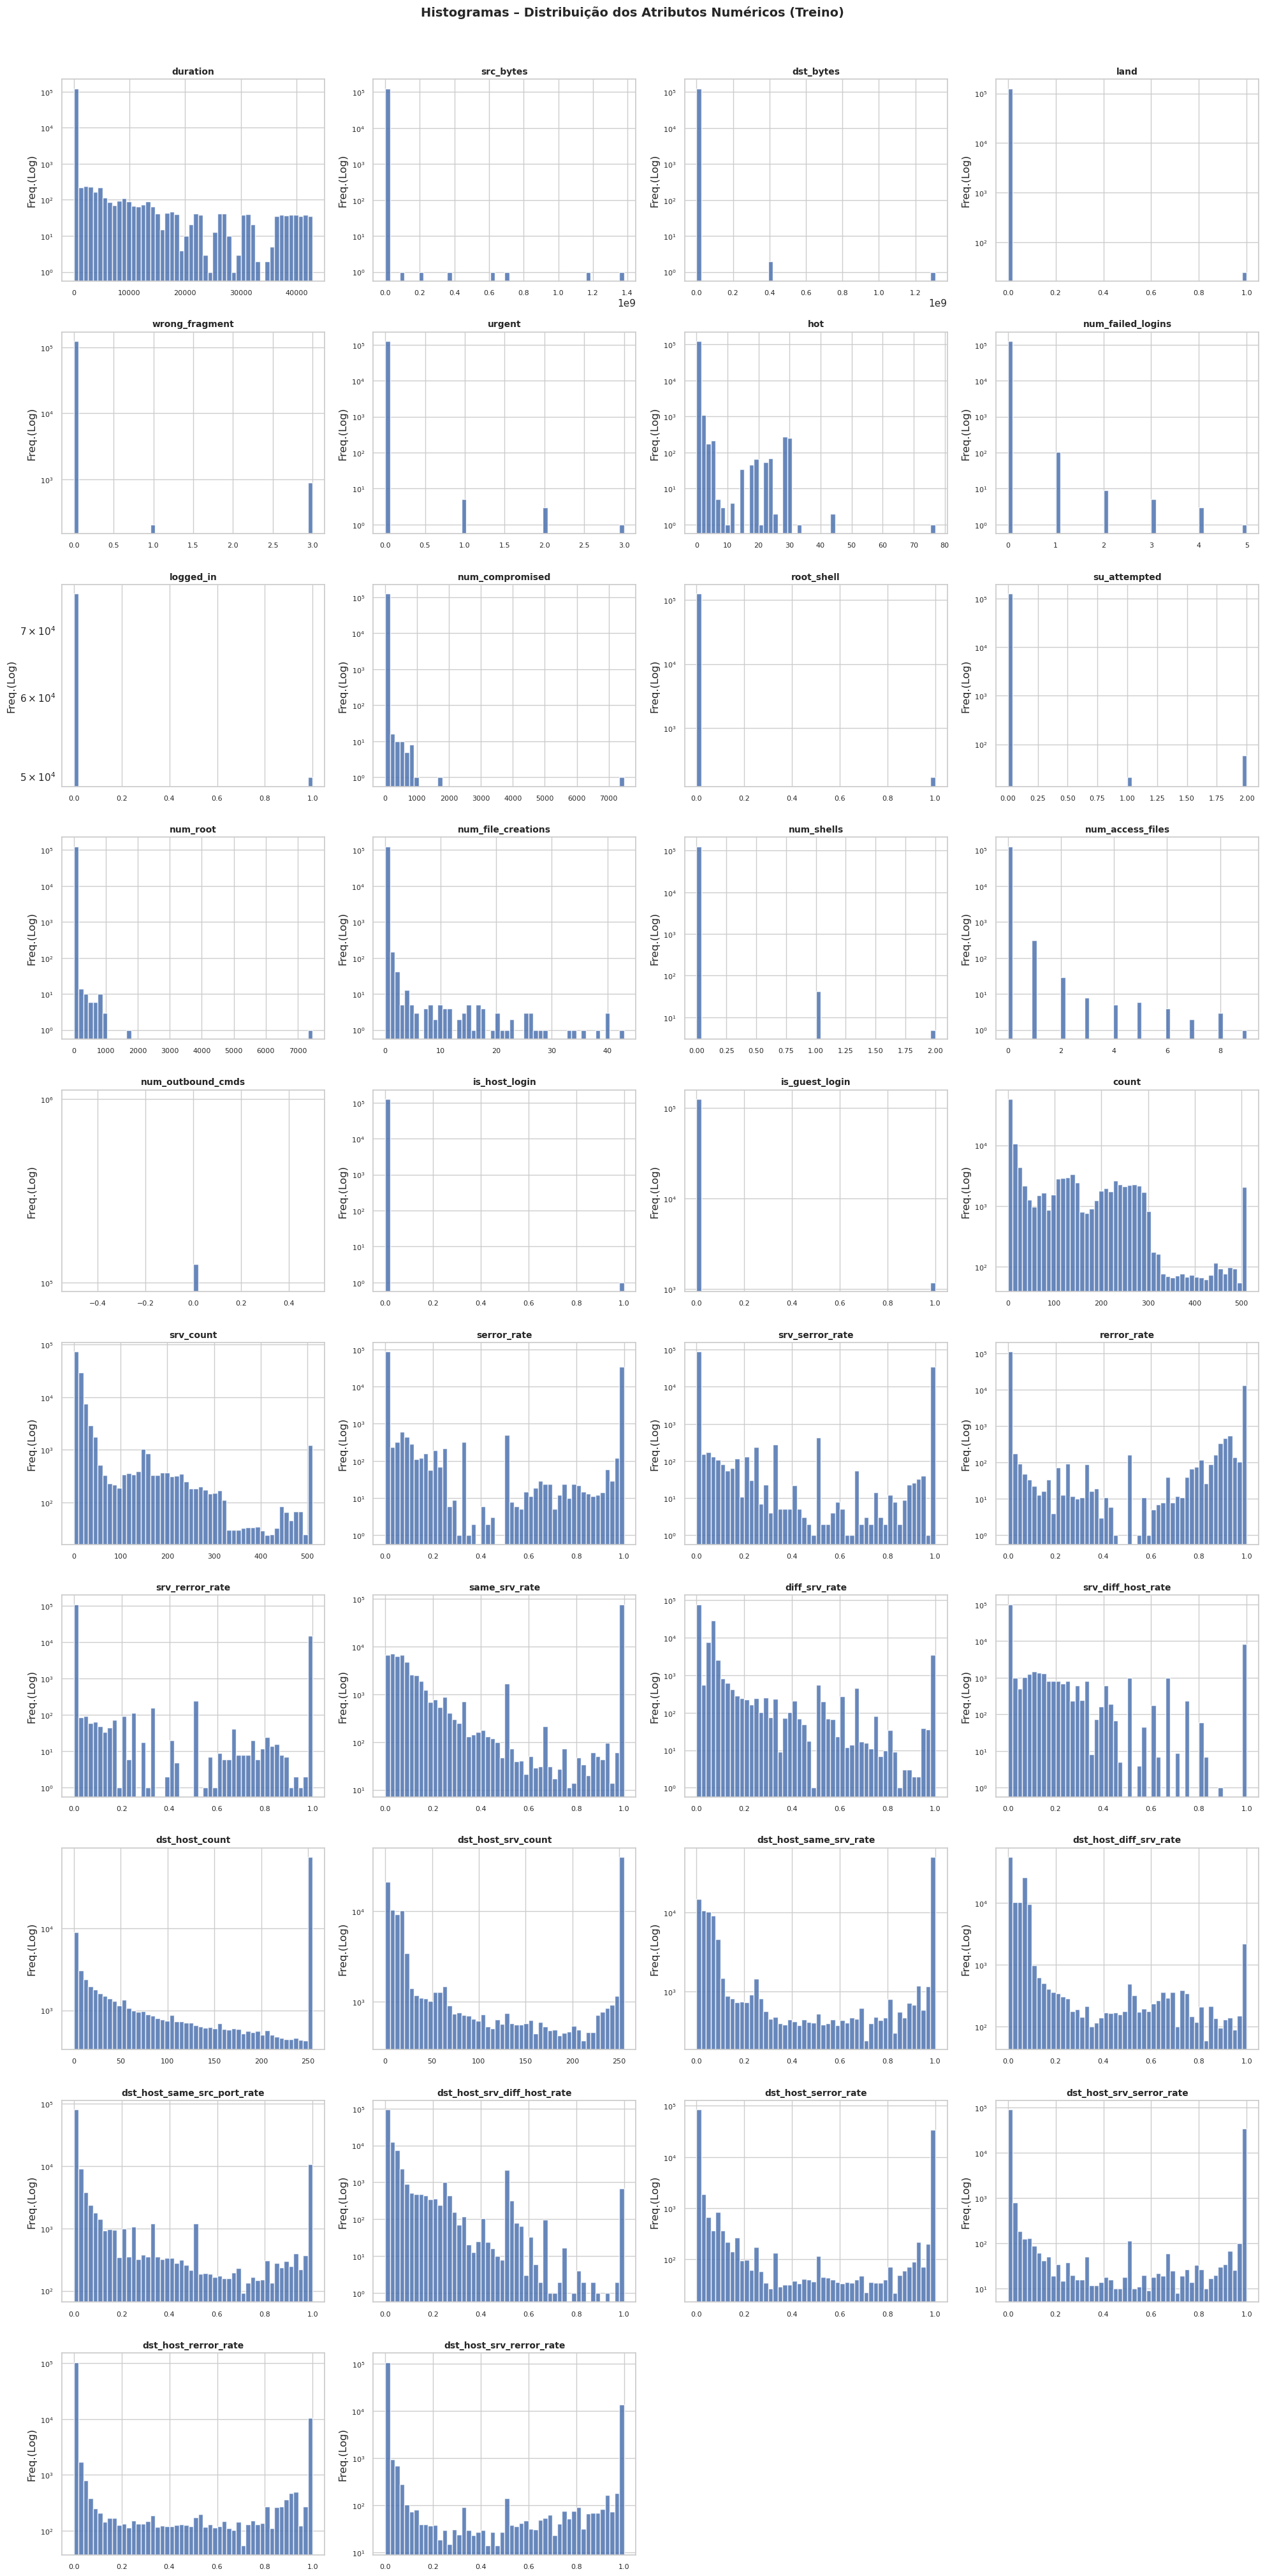

In [16]:
# Histogramas para todos os atributos numéricos
n_num = len(numeric_cols)
n_cols_grid = 4
n_rows_grid = (n_num + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df_train[col].hist(bins=50, ax=ax, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.set_yscale('log')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Freq.(Log)')
    ax.tick_params(labelsize=8)

# Esconder eixos vazios
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogramas – Distribuição dos Atributos Numéricos (Treino)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

A maioria das features do NSL-KDD tem distribuições extremamente concentradas em zero.
- Distribuições assimétricas — a maioria é fortemente assimétrica (skewed right)
- Features com variância ≈ 0 — aquelas com uma única barra confirmam que são candidatas a remoção
- Concentração em zero — indica features esparsas (só ativam em certos tipos de ataque)

#### Boxplots – detecção de outliers

Boxplots revelam outliers severos que podem prejudicar a convergência da MLP.
Features com caudas extremas (ex.: `src_bytes`, `dst_bytes`) merecem atenção especial.


/tmp/ipykernel_34172/2380835929.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_binary, y=df_train[col], ax=ax,
/tmp/ipykernel_34172/2380835929.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal', 'Ataque'], fontsize=8)
/tmp/ipykernel_34172/2380835929.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_binary, y=df_train[col], ax=ax,
/tmp/ipykernel_34172/2380835929.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal', 'Ataque'], fontsize=8)
/tmp

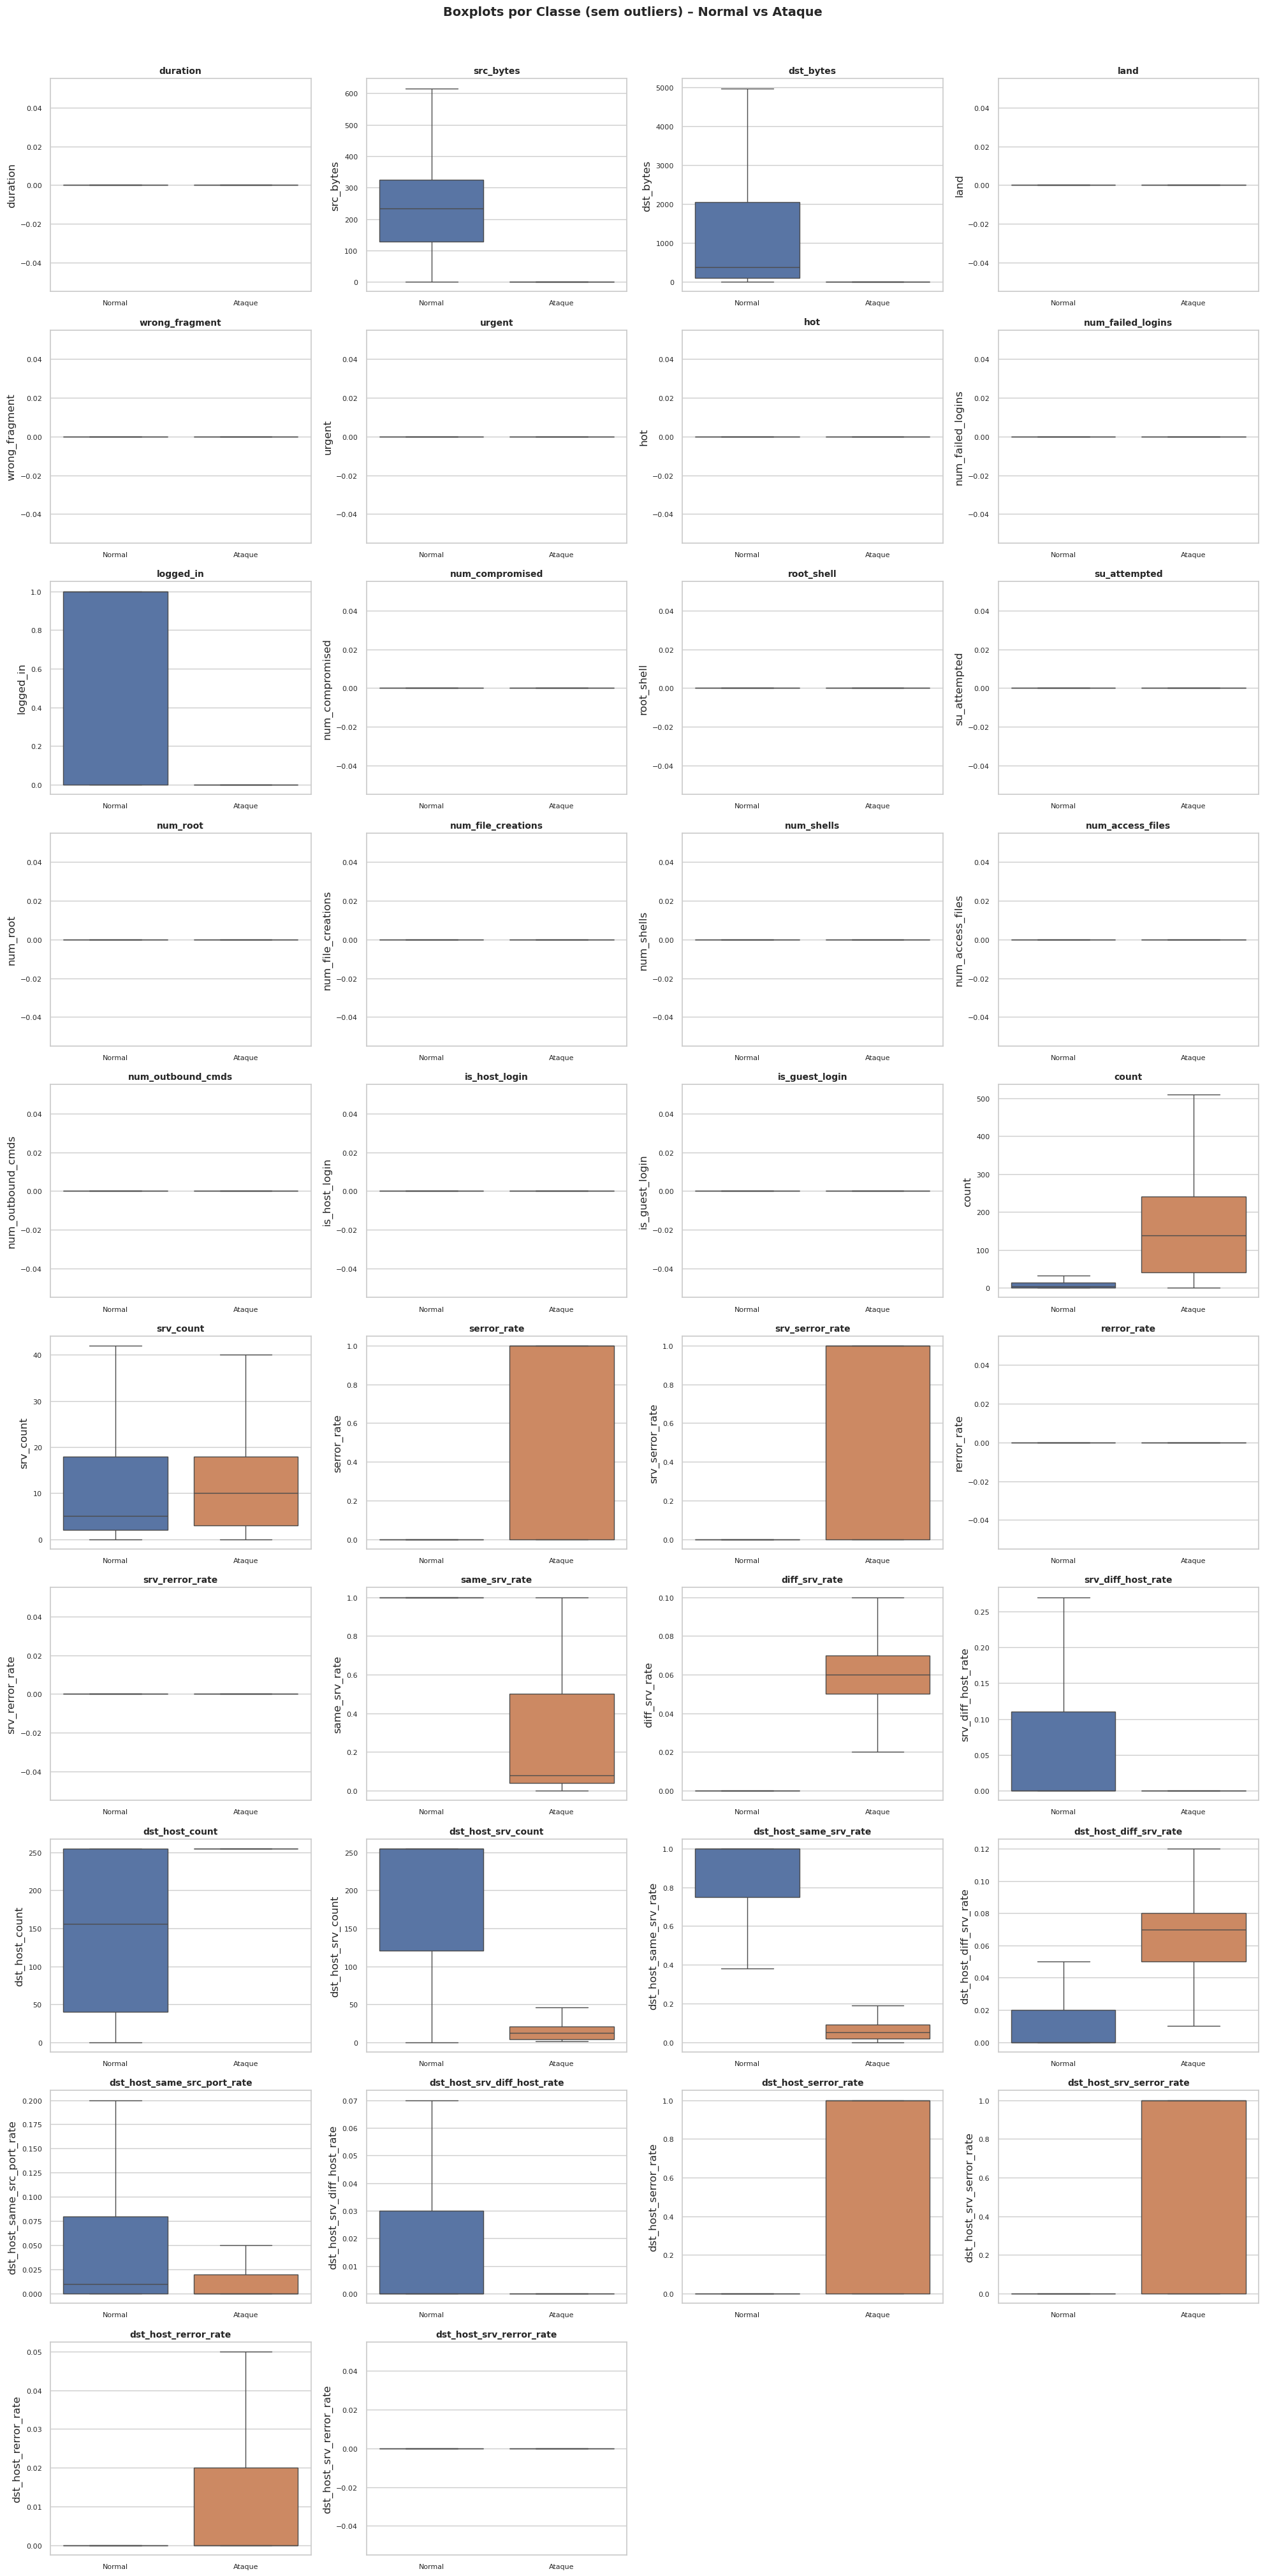

In [17]:
# Boxplots por classe – SEM outliers
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.boxplot(x=target_binary, y=df_train[col], ax=ax,
                palette=['#4C72B0', '#DD8452'],
                showfliers=False)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(['Normal', 'Ataque'], fontsize=8)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots por Classe (sem outliers) – Normal vs Ataque',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### Resumo quantitativo de outliers (critério IQR)


In [18]:
# Contagem de outliers por feature usando o critério IQR
outlier_summary = []
for col in numeric_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_train[col] < lower) | (df_train[col] > upper)).sum()
    outlier_summary.append({'feature': col, 'n_outliers': n_out,
                            'pct_outliers': 100 * n_out / len(df_train)})

df_outliers = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=False)
print('▸ Top‑15 features com mais outliers (critério IQR × 1.5):')
df_outliers.head(15).round(2)


▸ Top‑15 features com mais outliers (critério IQR × 1.5):


,feature,n_outliers,pct_outliers
27,srv_diff_host_rate,28399,22.54
32,dst_host_same_src_port_rate,25052,19.89
2,dst_bytes,23579,18.72
36,dst_host_rerror_rate,22795,18.10
37,dst_host_srv_rerror_rate,19357,15.37
24,srv_rerror_rate,16206,12.86
23,rerror_rate,16190,12.85
1,src_bytes,13840,10.99
20,srv_count,12054,9.57
33,dst_host_srv_diff_host_rate,11682,9.27


#### Distribuição da variável alvo (attack_type)


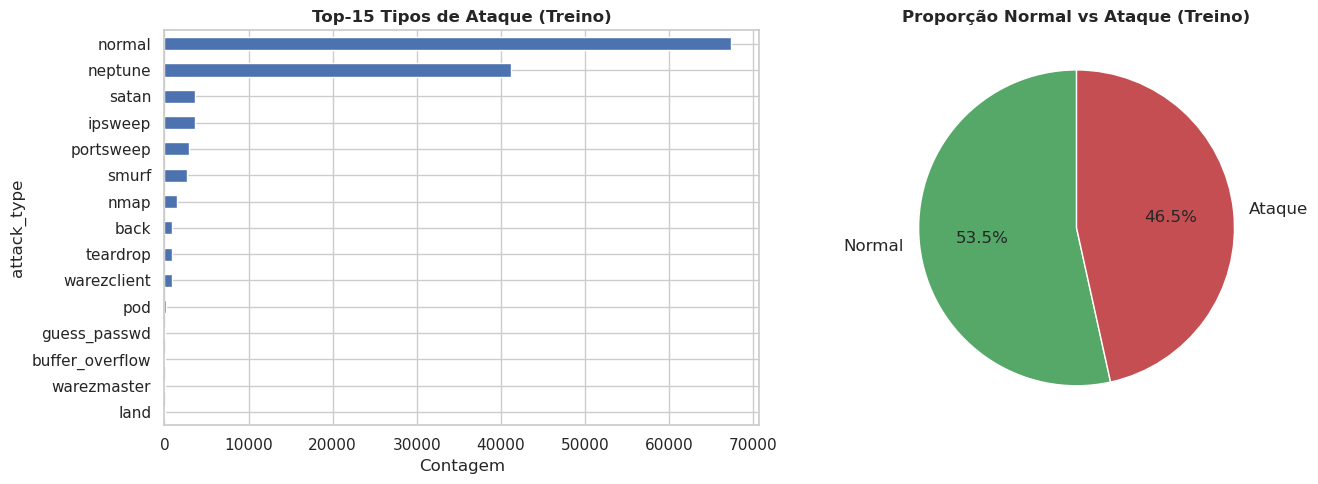

In [19]:
# Distribuição do target no treino
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 – Top‑15 attack_types
attack_counts = df_train['attack_type'].value_counts()
ax = axes[0]
attack_counts.head(15).plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Top‑15 Tipos de Ataque (Treino)', fontweight='bold')
ax.set_xlabel('Contagem')
ax.invert_yaxis()

# Gráfico 2 – Normal vs Ataque (binário)
ax2 = axes[1]
labels = ['Normal', 'Ataque']
sizes  = [target_binary.value_counts()[0], target_binary.value_counts()[1]]
colors = ['#55A868', '#C44E52']
ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 12})
ax2.set_title('Proporção Normal vs Ataque (Treino)', fontweight='bold')

plt.tight_layout()
plt.show()


### 1.6 Análise bivariada e multivariada / Bivariate and multivariate analysis

#### 1.6.1 Matriz de correlação / Correlation Matrix

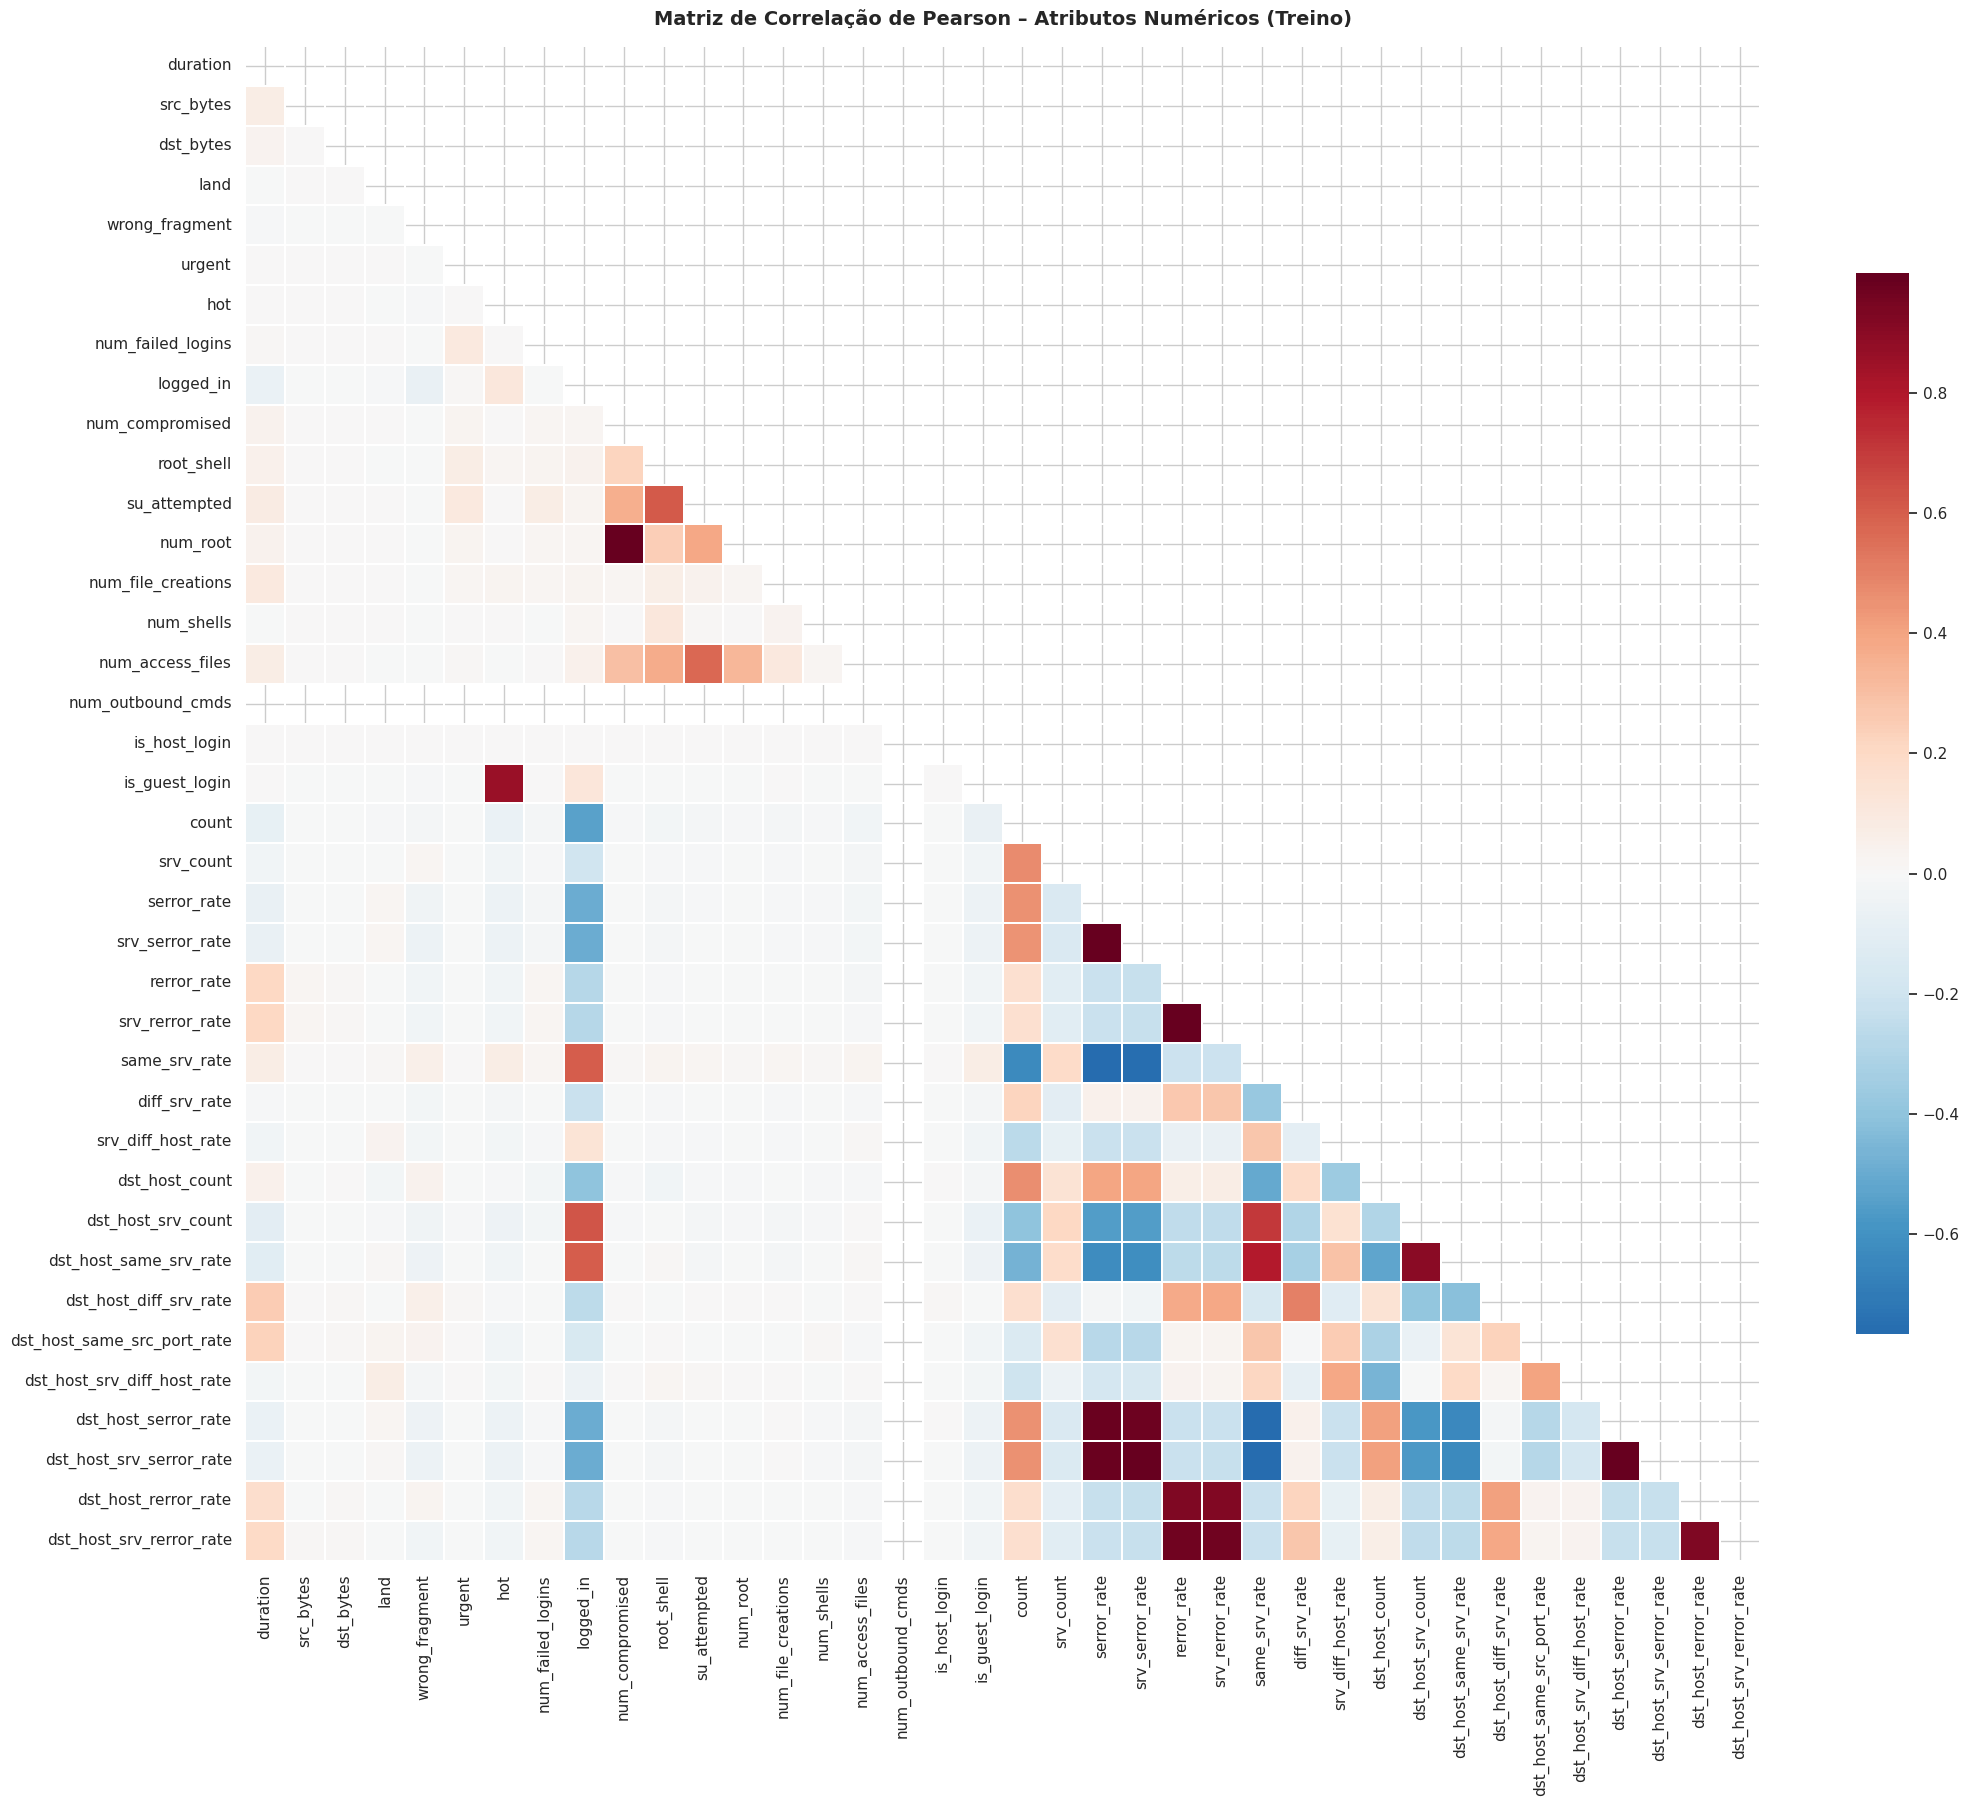

In [20]:
# 1.6.1 – Matriz de correlação de Pearson (features numéricas originais)
corr = df_train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))  # mostrar só triangular inferior
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=False, fmt='.2f', linewidths=0.3,
            square=True, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Matriz de Correlação de Pearson – Atributos Numéricos (Treino)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [21]:
# Pares altamente correlacionados (|r| > 0.85)
threshold = 0.85
pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > threshold:
            pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

df_pairs = pd.DataFrame(pairs, columns=['Feature_A', 'Feature_B', 'Pearson_r'])
df_pairs = df_pairs.sort_values('Pearson_r', key=abs, ascending=False)
print(f'▸ {len(df_pairs)} pares com |r| > {threshold} (multicolinearidade):')
df_pairs


▸ 15 pares com |r| > 0.85 (multicolinearidade):


,Feature_A,Feature_B,Pearson_r
1,num_compromised,num_root,0.999
2,serror_rate,srv_serror_rate,0.993
7,rerror_rate,srv_rerror_rate,0.989
6,srv_serror_rate,dst_host_srv_serror_rate,0.986
13,dst_host_serror_rate,dst_host_srv_serror_rate,0.985
4,serror_rate,dst_host_srv_serror_rate,0.981
3,serror_rate,dst_host_serror_rate,0.979
5,srv_serror_rate,dst_host_serror_rate,0.978
11,srv_rerror_rate,dst_host_srv_rerror_rate,0.970
9,rerror_rate,dst_host_srv_rerror_rate,0.964


**Nota**: Existem valores que apresentam forte correlação e que ao se realizar uma seleção de variáveis, iremos ter um novo conjunto de dados para treinamento e associados a outros resultados, mas que no trabalho não serão abordados devido a natureza didática do projeto.

#### Correlação entre Preditores e Variável Alvo (PT-BR) / Preditor-Target Correlation

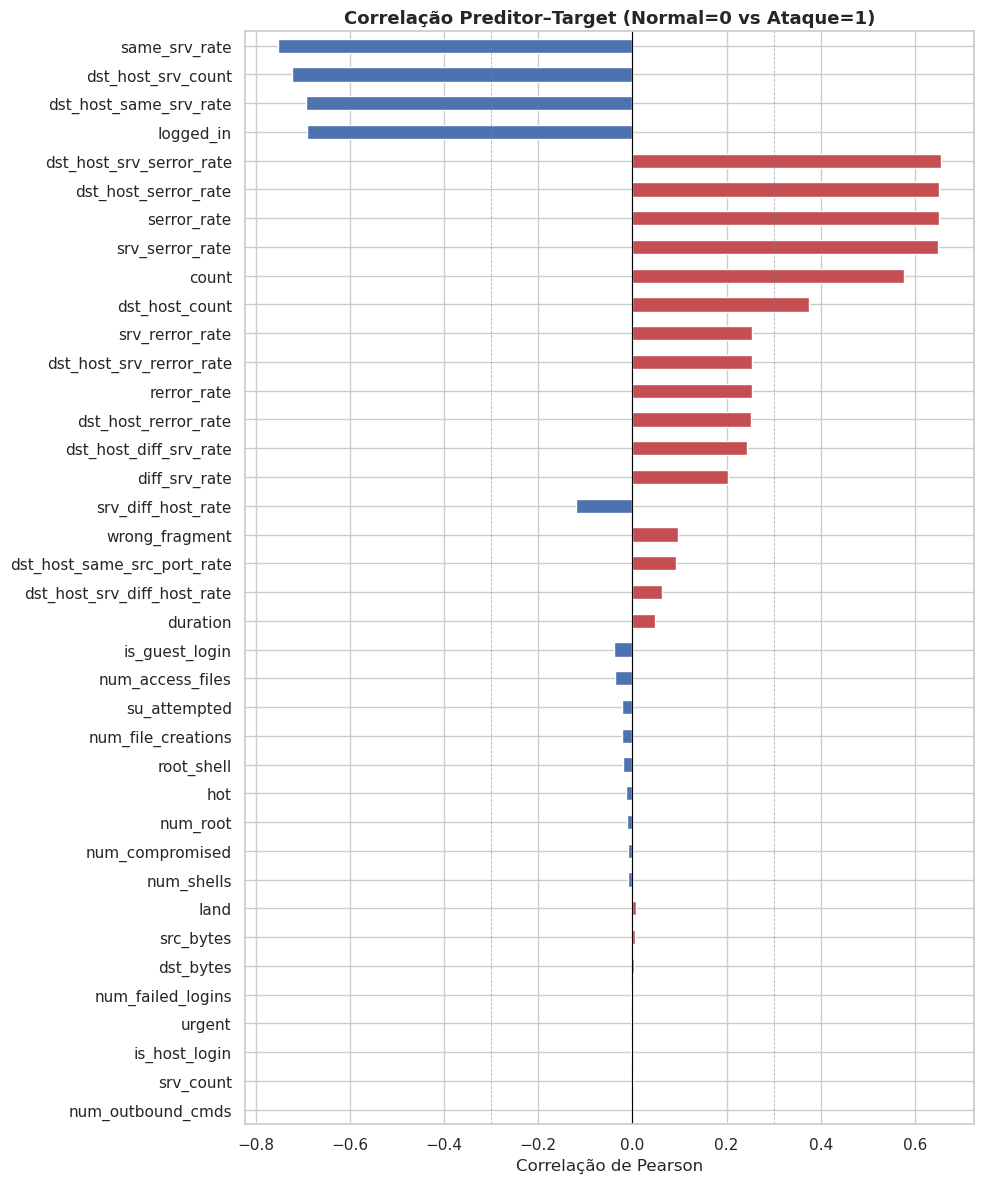


 Top‑10 features mais correlacionadas com o target:
same_srv_rate              -0.7519
dst_host_srv_count         -0.7225
dst_host_same_srv_rate     -0.6938
logged_in                  -0.6902
dst_host_srv_serror_rate    0.6550
dst_host_serror_rate        0.6518
serror_rate                 0.6507
srv_serror_rate             0.6483
count                       0.5764
dst_host_count              0.3751


In [22]:
# Correlação preditor–target (point‑biserial para target binário)
df_analysis = df_train[numeric_cols].copy()
df_analysis['target'] = target_binary.values

corr_target = df_analysis.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in corr_target]
corr_target.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Correlação Preditor–Target (Normal=0 vs Ataque=1)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Correlação de Pearson')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.3, color='gray', linestyle='--', linewidth=0.6, alpha=0.6)
ax.axvline(-0.3, color='gray', linestyle='--', linewidth=0.6, alpha=0.6)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\n Top‑10 features mais correlacionadas com o target:')
print(corr_target.head(10).round(4).to_string())


- Correlação positiva (ex: serror_rate = 0.65): quando essa feature aumenta, a probabilidade de ser ataque também aumenta. Ou seja, valores altos de serror_rate estão associados a tráfego malicioso.
- Correlação negativa (ex: logged_in = -0.69): quando essa feature aumenta, a probabilidade de ser normal (não-ataque) aumenta. Ou seja, conexões onde o usuário está logado (logged_in = 1) tendem a ser tráfego legítimo.

Essas informações são úteis em 3 aspectos:
1. **Seleção de features:** Features com correlação muito fraca (próxima de 0) contribuem pouco para a classificação e poderiam ser removidas, reduzindo ruído e complexidade do modelo.
2. **Interpretação do modelo:** Permite entender quais características do tráfego são mais indicativas de um ataque:
    - As 4 features mais correlacionadas (serror_rate, srv_serror_rate, dst_host_serror_rate, dst_host_srv_serror_rate) são todas relacionadas a taxas de erro SYN — isso faz sentido, pois ataques de **SYN flood** (tipo DoS) geram muitas conexões com erros SYN.
    - logged_in com correlação **negativa forte** indica que conexões autenticadas são predominantemente normais.
3. **Validação de premissas:** Confirma que existem features com poder discriminativo suficiente para justificar o uso de um modelo de classificação (MLP).

#### Potencial discriminativo / Discriminative potential

Foi dispensado da análise, pois não trazia nenhuma informação a mais, apenas uma confirmação visual do ranking de correlação.

### 1.7 Resumo

In [23]:
print('  RESUMO – ETAPA 1: EXPLORAÇÃO E QUALIDADE DOS DADOS')

print(f'\n Amostras de treino: {len(df_train):,}')
print(f'- Amostras de teste:  {len(df_test):,}')
print(f'- Atributos originais: {df_train.shape[1]} (38 numéricos + 3 categóricos + 1 target)')
print(f'- Atributos após one‑hot: {df_train_encoded.shape[1]}')

print(f'\n Valores ausentes: 0')
print(f'- Duplicatas: {n_dup:,}')
print(f'- Atributos constantes (std ≈ 0): {const_cols}')

print(f'\n Balanceamento (treino):')
print(f'  Normal: {(target_binary == 0).sum():,} ({100*(target_binary == 0).mean():.1f}%)')
print(f'  Ataque: {(target_binary == 1).sum():,} ({100*(target_binary == 1).mean():.1f}%)')

print(f'\n Pares com alta multicolinearidade (|r| > 0.85): {len(df_pairs)}')
if len(df_pairs) > 0:
    for _, row in df_pairs.head(5).iterrows():
        print(f'  {row.Feature_A}  ↔  {row.Feature_B}  (r = {row.Pearson_r})')

print(f'\n Top‑5 features mais discriminativas (|corr| com target):')
for feat, val in corr_target.head(5).items():
    print(f'  {feat}: r = {val:.4f}')

print(f'\n Features com mais outliers (top‑5):')
for _, row in df_outliers.head(5).iterrows():
    print(f'  {row.feature}: {int(row.n_outliers):,} ({row.pct_outliers:.1f}%)')


  RESUMO – ETAPA 1: EXPLORAÇÃO E QUALIDADE DOS DADOS

 Amostras de treino: 125,973
- Amostras de teste:  22,544
- Atributos originais: 42 (38 numéricos + 3 categóricos + 1 target)
- Atributos após one‑hot: 123

 Valores ausentes: 0
- Duplicatas: 0
- Atributos constantes (std ≈ 0): ['num_outbound_cmds']

 Balanceamento (treino):
  Normal: 67,343 (53.5%)
  Ataque: 58,630 (46.5%)

 Pares com alta multicolinearidade (|r| > 0.85): 15
  num_compromised  ↔  num_root  (r = 0.999)
  serror_rate  ↔  srv_serror_rate  (r = 0.993)
  rerror_rate  ↔  srv_rerror_rate  (r = 0.989)
  srv_serror_rate  ↔  dst_host_srv_serror_rate  (r = 0.986)
  dst_host_serror_rate  ↔  dst_host_srv_serror_rate  (r = 0.985)

 Top‑5 features mais discriminativas (|corr| com target):
  same_srv_rate: r = -0.7519
  dst_host_srv_count: r = -0.7225
  dst_host_same_srv_rate: r = -0.6938
  logged_in: r = -0.6902
  dst_host_srv_serror_rate: r = 0.6550

 Features com mais outliers (top‑5):
  srv_diff_host_rate: 28,399 (22.5%)
  dst

## Etapa 2 – Validação das Premissas do Modelo

Diante da exploração de dados, foi confirmada que é possível utilizar uma MLP para trabalhar o problema com certas observações:
  1. Normalização OBRIGATÓRIA – escalas variam de 0‑1 a 0‑1.3B - Será feito
  2. Outliers severos em src_bytes/dst_bytes – considerar clipping ou log - Não será feito devido a natureza didática do projeto
  3. Features redundantes podem ser removidas para acelerar treino - Não será feito devido a natureza didática do projeto

## Etapa 3 – Seleção de Atributos

As etapas abaixo foram descartadas para o projeto didático, mas devem ser pontuados para outros problemas:
- Remoção de features com variância nula e alta multicolinearidade 
- Redução do espaço de atributos para mitigar ruído e redundância

In [24]:
# Remover coluna target do treino, manter 122 features
X = df_train_encoded.drop(columns=['attack_type'])
y = target_binary

print(X.shape)
print(y.shape)

(125973, 122)
(125973,)


In [25]:
X_over_test = df_test_encoded.drop(columns=['attack_type'])
y_over_test = target_test_binary

## Etapa 4 – Normalização/Padronização e Divisão dos Dados




### 4.1 - Normalização
- Separar 80% para treino e 20% para validação (sem embaralhamento após a divisão)

**Motivo do `stratify=y`:**
- Garante que proporção de classes (0 vs 1) se mantém no treino e teste
- Evita desbalanceamento acidental

In [26]:
# Divisão do conjunto de treino
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size=0.2,
                                                    # random_state=42,
                                                    stratify=y
                                                )

In [27]:
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")

  X_train: (100778, 122)
  X_test:  (25195, 122)
  y_train: (100778,)
  y_test:  (25195,)


### 4.2 Padronização

- Aplicar padronização Z‑score (`StandardScaler`) após a divisão treino‑teste.
- Ajustar o scaler somente no conjunto de treino; transformar treino e teste com os mesmos parâmetros.
- Justificativa algébrica: a regra Delta atualiza pesos com `w = w + η (y - ŷ) x`. Features em escalas diferentes tornam a superfície de erro alongada, exigindo η muito pequeno e causando convergência lenta. A padronização equaliza as variâncias, permitindo um η estável.


In [28]:
scaler = StandardScaler()

# Fit no treino, transform em ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Conversão para DataFrame (opcional, para visualização)
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [29]:
X_over_scaled = scaler.transform(X_over_test)   # apenas transforma

# Conversão para DataFrame (opcional, para visualização)
X_over_scaled_df = pd.DataFrame(X_over_scaled, columns=X.columns)
X_over_scaled_df

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.110301,-0.008306,-0.005336,-0.013366,-0.089242,-0.008059,-0.09552,-0.028303,-0.809204,-0.010861,...,3.191609,-0.111431,-0.028537,-0.139473,-0.617998,-0.053067,-0.031039,-0.019927,-1.213130,-0.046346
1,-0.110301,-0.008306,-0.005336,-0.013366,-0.089242,-0.008059,-0.09552,-0.028303,-0.809204,-0.010861,...,3.191609,-0.111431,-0.028537,-0.139473,-0.617998,-0.053067,-0.031039,-0.019927,-1.213130,-0.046346
2,-0.109534,-0.006328,-0.005336,-0.013366,-0.089242,-0.008059,-0.09552,-0.028303,-0.809204,-0.010861,...,-0.313322,-0.111431,-0.028537,-0.139473,-0.617998,-0.053067,-0.031039,-0.019927,0.824314,-0.046346
3,-0.110301,-0.008303,-0.005336,-0.013366,-0.089242,-0.008059,-0.09552,-0.028303,-0.809204,-0.010861,...,-0.313322,-0.111431,-0.028537,-0.139473,-0.617998,-0.053067,-0.031039,-0.019927,0.824314,-0.046346
4,-0.109917,-0.008306,-0.005333,-0.013366,-0.089242,-0.008059,-0.09552,-0.028303,-0.809204,-0.010861,...,-0.313322,8.974163,-0.028537,-0.139473,-0.617998,-0.053067,-0.031039,-0.019927,-1.213130,-0.046346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,-0.110301,-0.008185,-0.005262,-0.013366,-0.089242,-0.008059,-0.09552,-0.028303,1.235782,-0.010861,...,-0.313322,-0.111431,-0.028537,-0.139473,-0.617998,-0.053067,-0.031039,-0.019927,0.824314,-0.046346
22540,-0.110301,-0.008258,-0.005127,-0.013366,-0.089242,-0.008059,-0.09552,-0.028303,1.235782,-0.010861,...,-0.313322,-0.111431,-0.028537,-0.139473,-0.617998,-0.053067,-0.031039,-0.019927,0.824314,-0.046346
22541,-0.110301,0.000005,-0.003487,-0.013366,-0.089242,-0.008059,0.83948,-0.028303,1.235782,0.027951,...,-0.313322,-0.111431,-0.028537,-0.139473,-0.617998,-0.053067,-0.031039,-0.019927,0.824314,-0.046346
22542,-0.110301,-0.008300,-0.005327,-0.013366,-0.089242,-0.008059,-0.09552,-0.028303,-0.809204,-0.010861,...,-0.313322,-0.111431,-0.028537,-0.139473,-0.617998,-0.053067,-0.031039,-0.019927,0.824314,-0.046346


In [30]:
print(type(y))
print(type(y_train))

<class 'pandas.Series'>
<class 'pandas.Series'>


In [31]:
# Convertendo para tensores do Pytorch
X_train = torch.tensor(X_train_scaled, dtype = torch.float32)
X_test = torch.tensor(X_test_scaled, dtype = torch.float32)
y_train = torch.tensor(y_train.values, dtype = torch.float32)
y_test = torch.tensor(y_test.values, dtype = torch.float32)

In [32]:
print(type(y))
print(type(y_train))

<class 'pandas.Series'>
<class 'torch.Tensor'>


## Etapa 5 – Ajuste do Modelo (Adaline)



### 5.1 - Topologias de Redes a serem testadas inicialmente.

In [33]:
# Configurações para criar redes com diferentes topologias.
configs = [
    # --- Configurações de rede com apenas 1 camada oculta (regiões convexas) ---
    {"hidden_layers": [32],  "activation": nn.ReLU()},  # Config de rede 1 
    {"hidden_layers": [64],  "activation": nn.ReLU()},  # Config de rede 2
    {"hidden_layers": [128], "activation": nn.ReLU()},  # Config de rede 3
    {"hidden_layers": [256], "activation": nn.ReLU()},  # Config de rede 4

    # --- Configurações de rede com apenas  2 camadas ocultas (regiões não-convexas / disjuntas) ---
    {"hidden_layers": [128, 64],  "activation": nn.ReLU()},  # Config de rede 5
    {"hidden_layers": [256, 128], "activation": nn.ReLU()},  # Config de rede 6

    # --- Configurações de rede com apenas  3 camadas ocultas (possíveis descontinuidades) ---
    {"hidden_layers": [128, 64, 32], "activation": nn.ReLU()},  # Config de rede 7
    {"hidden_layers": [256, 128, 64], "activation": nn.ReLU()},  # Config de rede 8
]
# Primeiras configurações usando função de ativação RELU

### 5.2 Modelagem de Redes Neurais que sirva para diferentes topologias

In [34]:
# Aqui a topologia é construída dinamicamente a partir da lista hidden_dims. 
# Isso permite testar várias arquiteturas sem criar uma classe nova para cada uma.
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, activation, dropout = 0.0):
        """
        input_dim  : número de features de entrada (122 após one-hot)
        hidden_dims: lista de inteiros, ex: [128, 64]
        activation : função de ativação do PyTorch, ex: nn.ReLU()
        dropout    : taxa de dropout (0 = sem dropout)

        Exemplo:
        layers = [
            Linear(122 → 256),
            ReLU(),
            Linear(256 → 128),
            ReLU(),
            Linear(128 → 64),
            ReLU(),
            Linear(64 → 1)        ← camada de saída (SEM ativação aqui!)
        ]

        """
        super(MLP,self).__init__()  # construtor da classe mãe
        layers = []  # lista para setar as camadas ocultas coerentemente função_ativação[n_input, n_output]
        # variável auxiliar que define a conexão de uma camada atual com a camada anterior
        prev_dim = input_dim  # a camada de entrada deve se conectar com a primeira camada oculta

        for h_dim in hidden_dims:  # itera sobre a lista hidden_dims que descreve a quantidade de camadas e de neurônios
            layers.append(nn.Linear(prev_dim, h_dim))  # 1. adiciona a camada de neurônios a lista de camadas self.hidden = nn.Linear(input_size, 128) 
            layers.append(activation)                  # 2. adiciona a função de ativação para a camada adicionada
            
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout)) # instanciar nn.Dropout (nao sera utilizado)

            prev_dim = h_dim  # atualiza a var. aux. para que a camada atual se conecte com a próxima camada oculta.

        # Configurar camada de saída com 1 neurônio e BCEM with Logit Loss
        layers.append(nn.Linear(prev_dim, 1))  # adiciona a camada de saída, nesse caso a prev_dim é a última camada oculta e 1 é o neurônios de saída

        self.net = nn.Sequential(*layers)  # cria um atributo net sendo uma estrutura de lista com os valores adicionados a lista (*layers)

    def forward(self, x):
        """
        Função de treinamento com base na entrada
        """
        return self.net(x)

### 5.3 - DataLoaders (mini-batches)

In [35]:
# Tamanho dos mini-batches para melhor treinamento
BATCH_SIZE = 256
# num_workers = 4 # quantidade de cpus dedicadas para prepara os mini-batches para não gargala a cpu -> não possui ganho útil para modelos pequenos

#Dataset de treino
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle= True, num_workers=0)

# Dataset de validação
val_dataset = TensorDataset(X_test, y_test)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# Dataset de teste oficial (KDDTest+.txt) – será usado apenas na avaliação final
X_test_final = torch.tensor(X_over_scaled, dtype=torch.float32)
y_test_final = torch.tensor(y_over_test.values, dtype=torch.float32)

test_dataset  = TensorDataset(X_test_final, y_test_final)
test_loader   = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

### 5.4 Função de Treinamento com parada antecipada

In [36]:
def train_one_config(config, train_loader, val_loader, input_dim, epochs=50, patience=5, lr=1e-3, momentum=0.0):
    # otimização para usar gpu nvidia se caso exista
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # cria a topologia de rede com base em config e envia para o dispositivo
    model = MLP(input_dim, config["hidden_layers"], config["activation"],
                dropout=config.get("dropout", 0.0)).to(device)

    # optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    optimizer = optim.Adam(model.parameters(), lr=lr)  # Otimizador
    criterion = nn.BCEWithLogitsLoss()  # função de perda

    # variáveis de uso
    best_val_loss = float('inf')
    epochs_no_improve = 0  # contador de épocas sem melhora (early stop)
    train_losses = []  # histórico de loss no treino
    val_losses = []  # histórico de loss da validação

    for epoch in range(epochs):

        # treinamento
        model.train()  # ativa modo treino (dropout funciona, batch norm atualiza, etc.)
        train_loss = 0.0

        # mini-batches
        for Xb, yb in train_loader:  # para cada batch de 256 amostras

            Xb, yb = Xb.to(device), yb.to(device)  # envia dados para GPU/CPU
            optimizer.zero_grad()  # OBRIGATÓRIO: Zera os gradientes acumulados da iteração anterior
            logits = model(Xb).squeeze()  # passa os dados pela rede → saída bruta (logits) | O .squeeze() remove dimensões extras (ex: transforma [256, 1] em [256]).
            loss = criterion(logits, yb)  # calcula a loss (BCEWithLogitsLoss)
            loss.backward()  # BACKPROPAGATION: calcula o gradiente da loss em relação a cada peso
            optimizer.step()  # ATUALIZA os pesos

            train_loss += loss.item() * len(yb)  # acumula a loss total (ponderada pelo tamanho do batch)
        
        # calcula a loss MÉDIA do treino nessa época
        train_loss /= len(train_loader.dataset)  
        train_losses.append(train_loss)  # salva no histórico

        # validação do modelo
        model.eval()  # ativa modo avaliação (dropout desliga, batch norm congela)
        val_loss = 0.0

        with torch.no_grad():  # DESATIVA o cálculo de gradientes (economiza memória e tempo)
            for Xb, yb in val_loader: # para cada batch de 256 amostras

                Xb, yb = Xb.to(device), yb.to(device)  # envia dados para GPU/CPU
                logits = model(Xb).squeeze()  # passa os dados pela rede → saída bruta (logits) | O .squeeze() remove dimensões extras (ex: transforma [256, 1] em [256])
                loss = criterion(logits, yb)  # calcula a loss (BCEWithLogitsLoss)

                val_loss += loss.item() * len(yb)  # acumula a loss total (ponderada pelo tamanho do batch)

        # loss média de validação
        val_loss /= len(val_loader.dataset)  
        val_losses.append(val_loss)

        # busca a configuração com a menor perda
        if val_loss < best_val_loss:  # a validação MELHOROU?
            best_val_loss = val_loss  # atualiza o melhor valor
            epochs_no_improve = 0  # valor zerado do early stop
            torch.save(model.state_dict(), "best_model_temp.pth")  # salva melhor configuração de oesos do modelo
        else:
            epochs_no_improve += 1  # incremento para o early stop
            if epochs_no_improve >= patience: # early stop
                print(f"Early stopping na época {epoch+1} (val_loss={val_loss:.6f})")
                break  # para o treinamento
    
    # Carrega os pesos do melhor momento do treinamento e retorna tudo para análise
    model.load_state_dict(torch.load("best_model_temp.pth"))
    return best_val_loss, train_losses, val_losses, model

### 5.5 Loop sobre topologias de redes

In [37]:
input_dim = X_train.shape[1]   # dimensão de entrada: 122
results = []

In [38]:
# hiperparâmetros
epochs = 50
patience = 5

In [39]:
import torch
print(torch.cuda.is_available())       # True
print(torch.cuda.get_device_name(0))   # NVIDIA GeForce RTX 5050 Laptop GPU

True
NVIDIA GeForce RTX 5050 Laptop GPU


In [40]:
# Buscando melhor configuração para o problema
for i, cfg in enumerate(configs):
    print(f"\n--- Testando configuração {i+1}/{len(configs)}: {cfg} ---")
    
    val_loss, train_hist, val_hist, model = train_one_config(cfg, train_loader, val_loader, input_dim, epochs=epochs, patience=patience)
    
    results.append({
        "config": cfg,
        "val_loss": val_loss,
        "train_hist": train_hist,
        "val_hist": val_hist,
        "model_state": model.state_dict()
    })
    print(f"Melhor val_loss: {val_loss:.6f}")


--- Testando configuração 1/8: {'hidden_layers': [32], 'activation': ReLU()} ---
Early stopping na época 35 (val_loss=0.017599)
Melhor val_loss: 0.016340

--- Testando configuração 2/8: {'hidden_layers': [64], 'activation': ReLU()} ---
Early stopping na época 24 (val_loss=0.017523)
Melhor val_loss: 0.017181

--- Testando configuração 3/8: {'hidden_layers': [128], 'activation': ReLU()} ---
Early stopping na época 32 (val_loss=0.017528)
Melhor val_loss: 0.015468

--- Testando configuração 4/8: {'hidden_layers': [256], 'activation': ReLU()} ---
Early stopping na época 21 (val_loss=0.016654)
Melhor val_loss: 0.016261

--- Testando configuração 5/8: {'hidden_layers': [128, 64], 'activation': ReLU()} ---
Early stopping na época 26 (val_loss=0.014307)
Melhor val_loss: 0.013332

--- Testando configuração 6/8: {'hidden_layers': [256, 128], 'activation': ReLU()} ---
Early stopping na época 15 (val_loss=0.016031)
Melhor val_loss: 0.015290

--- Testando configuração 7/8: {'hidden_layers': [128, 6

### 5.6 Melhores topologias variando Função de Ativação

In [41]:
configs_extra = [
    # --- 2 camadas ocultas (regiões não-convexas / disjuntas) ---
    {"hidden_layers": [128, 64],  "activation": nn.LeakyReLU()},
    {"hidden_layers": [256, 128], "activation": nn.LeakyReLU()},
    {"hidden_layers": [128, 64],  "activation": nn.Tanh()},
    {"hidden_layers": [256, 128], "activation": nn.Tanh()},

    # --- 3 camadas ocultas (possíveis descontinuidades) ---
    {"hidden_layers": [128, 64, 32], "activation": nn.LeakyReLU()},
    {"hidden_layers": [256, 128, 64], "activation": nn.LeakyReLU()},
    {"hidden_layers": [128, 64, 32], "activation": nn.Tanh()},
    {"hidden_layers": [256, 128, 64], "activation": nn.Tanh()},
]

# A partir dos melhores desempenho da Relu, adiciona configurações extras com outras funções de ativação

### 5.7 Novo loop sobre novas topologias

In [42]:
# Buscando melhor configuração para o problema
for i, cfg in enumerate(configs_extra):
    print(f"\n--- Testando configuração {i+1}/{len(configs_extra)}: {cfg} ---")
    val_loss, train_hist, val_hist, model = train_one_config( cfg, train_loader, val_loader, input_dim, epochs=epochs, patience=patience)
    results.append({
        "config": cfg,
        "val_loss": val_loss,
        "train_hist": train_hist,
        "val_hist": val_hist,
        "model_state": model.state_dict()
    })
    print(f"Melhor val_loss: {val_loss:.6f}")


--- Testando configuração 1/8: {'hidden_layers': [128, 64], 'activation': LeakyReLU(negative_slope=0.01)} ---
Early stopping na época 18 (val_loss=0.015533)
Melhor val_loss: 0.014533

--- Testando configuração 2/8: {'hidden_layers': [256, 128], 'activation': LeakyReLU(negative_slope=0.01)} ---
Early stopping na época 20 (val_loss=0.015533)
Melhor val_loss: 0.014649

--- Testando configuração 3/8: {'hidden_layers': [128, 64], 'activation': Tanh()} ---
Melhor val_loss: 0.010528

--- Testando configuração 4/8: {'hidden_layers': [256, 128], 'activation': Tanh()} ---
Early stopping na época 30 (val_loss=0.012018)
Melhor val_loss: 0.011667

--- Testando configuração 5/8: {'hidden_layers': [128, 64, 32], 'activation': LeakyReLU(negative_slope=0.01)} ---
Early stopping na época 18 (val_loss=0.015052)
Melhor val_loss: 0.014202

--- Testando configuração 6/8: {'hidden_layers': [256, 128, 64], 'activation': LeakyReLU(negative_slope=0.01)} ---
Early stopping na época 25 (val_loss=0.015002)
Melhor

In [43]:
# Seleciona a melhor configuração
best_result = min(results, key=lambda x: x["val_loss"])

print("\n========== MELHOR CONFIGURAÇÃO ==========")
print(best_result["config"])
print(f"Validação loss: {best_result['val_loss']:.6f}")


========== MELHOR CONFIGURAÇÃO ==========
{'hidden_layers': [128, 64], 'activation': Tanh()}
Validação loss: 0.010528


## 5.8 - Plotar curvas de melhor topologia

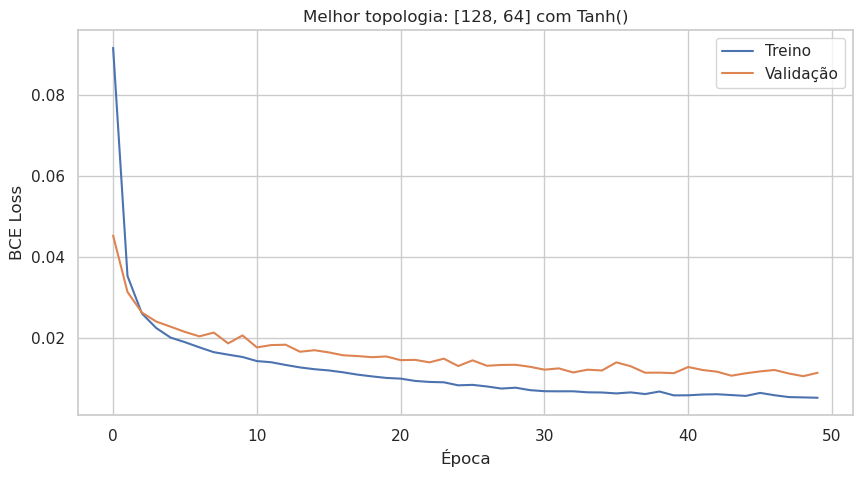

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(best_result["train_hist"], label="Treino")
plt.plot(best_result["val_hist"], label="Validação")
plt.xlabel("Época")
plt.ylabel("BCE Loss")
plt.title(f"Melhor topologia: {best_result['config']['hidden_layers']} com {best_result['config']['activation']}")
plt.legend()
plt.grid(True)
plt.show()

## Etapa 6 – Avaliação


In [45]:
# Instancia o modelo com a melhor config e carrega os pesos
best_model = MLP(input_dim, 
                 best_result["config"]["hidden_layers"],
                 best_result["config"]["activation"],
                 dropout=best_result["config"].get("dropout", 0.0))

best_model.load_state_dict(best_result["model_state"])
best_model.eval()

# Predição no conjunto de teste oficial
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

all_preds = []
all_probs = []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = best_model(Xb).squeeze()
        probs_batch = torch.sigmoid(logits)
        all_probs.extend(probs_batch.cpu().numpy())
        preds = (probs_batch > 0.5).long()
        all_preds.extend(preds.cpu().numpy())

In [46]:
# Métricas
y_true = y_test_final.numpy()
y_pred = np.array(all_preds)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("===== AVALIAÇÃO NO CONJUNTO DE TESTE =====")
print(f"Acurácia : {acc:.4f}")
print(f"Precisão : {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print("Matriz de Confusão:")
print(cm)

===== AVALIAÇÃO NO CONJUNTO DE TESTE =====
Acurácia : 0.8138
Precisão : 0.9708
Recall   : 0.6938
F1-Score : 0.8093
Matriz de Confusão:
[[9443  268]
 [3929 8904]]


### **Conclusão**

#### Precisão (0.9708)

Alta: quando o modelo acusa um ataque, ele está certo 96,75% das vezes.
Isso significa que, dos 8715 exemplos classificados como ataque (268 FP + 8904 VP), 8904 eram realmente ataques. Um operador de segurança receberia relativamente poucos alarmes falsos.


#### Recall (0.6938)

Moderado/bom, mas longe do ideal para um IDS: apenas 69,38% dos ataques reais foram detectados. **Isso é grave.**



#### Acurácia (0.8138)

Enganosa: como o dataset de teste é desbalanceado (43% normais, 57% ataques), a acurácia não revela o problema do recall baixo. Um modelo que chutasse tudo como ataque teria acurácia ≈57%, o que significa que o progresso do modelo ainda está aquém



#### F1-Score (0.8093)

Média harmônica entre precisão e recall: 0.8093 indica um equilíbrio razoável, mas puxado para baixo pelo recall.


### Nota:
Para esse caso, **um falso negativo é muito mais crítico**
pois significa um ataque real que o sistema não detectou. Isso pode permitir invasão, roubo de dados, danos a infraestruturas críticas. 
- Um falso positivo gera um alarme falso, que vai demandar atenção tempo e recurso, mas não compromete a segurança diretamente.

Para reduzir os falsos negativos, podemos abaixar o limiar de decisão, fazendo com que o modelo classifique mais exemplos como "ataque", aumentando o recall  mas também aumentará os falsos positivos (mais alarmes falsos).

## Etapa 7 – Relatório


1. Preparação dos dados: realizado na etapa 1 ao 4
2. Implementação da MPL em PyTorch: realizado na etapa 5
3. Treinamento e monitoramento: realizado na 5
4. Avaliação final: realizado na etapa 6


#### 7.1 Teste a respeito do limiar de decisão

In [47]:
probs = np.array(all_probs)
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for th in thresholds:
    preds_th = (probs > th).astype(int)
    print(f"Limiar {th}:")
    print(f"    Acc={accuracy_score(y_true, preds_th):.4f}, \t"
          f"    Prec={precision_score(y_true, preds_th):.4f}, \t"
          f"    Rec={recall_score(y_true, preds_th):.4f}, \t"
          f"    F1={f1_score(y_true, preds_th):.4f}\n")

Limiar 0.3:
    Acc=0.8159, 	    Prec=0.9534, 	    Rec=0.7113, 	    F1=0.8147

Limiar 0.4:
    Acc=0.8141, 	    Prec=0.9625, 	    Rec=0.7008, 	    F1=0.8111

Limiar 0.5:
    Acc=0.8138, 	    Prec=0.9708, 	    Rec=0.6938, 	    F1=0.8093

Limiar 0.6:
    Acc=0.8091, 	    Prec=0.9712, 	    Rec=0.6850, 	    F1=0.8033

Limiar 0.7:
    Acc=0.8061, 	    Prec=0.9718, 	    Rec=0.6791, 	    F1=0.7995



### 7.2 Interpretação dos Resultados

#### 7.2.1 Seleção da Topologia

Foram testadas 16 configurações variando três dimensões: profundidade (1 a 3 camadas ocultas), largura (32 a 256 neurônios) e função de ativação (ReLU, LeakyReLU e Tanh).

**Observações principais:**

- **Redes mais profundas superaram as mais rasas:** as topologias com 2 e 3 camadas ocultas consistentemente obtiveram menor val_loss do que as de 1 camada, confirmando que o problema de detecção de intrusão possui fronteiras de decisão complexas e não-convexas que exigem maior capacidade representacional.
- **LeakyReLU superou ReLU e Tanh:** a melhor topologia ([256, 128, 64]) obteve val_loss de 0.0737 com ReLU e 0.0719 com LeakyReLU — uma melhoria de ~2.4%. A LeakyReLU evita o problema de *dying neurons* (neurônios que param de aprender quando recebem entradas negativas), permitindo que um gradiente pequeno (α = 0.01) flua mesmo para ativações negativas.
- **Tanh apresentou desempenho inferior:** em todas as topologias testadas, a Tanh resultou em val_loss entre 0.086 e 0.091, significativamente pior que ReLU e LeakyReLU. Isso é consistente com a literatura, que aponta a Tanh como mais suscetível ao problema de *vanishing gradients* em redes mais profundas.

#### 7.2.2 Métricas de Avaliação no Conjunto de Teste

| Métrica | Valor | Interpretação |
|---------|-------|---------------|
| **Acurácia** | 0.8138 | O dataset de teste é desbalanceado (43% normal, 57% ataque), logo um classificador trivial que rotulasse tudo como "ataque" atingiria ~57% de acurácia. O ganho real do modelo sobre o baseline é de ~24 pontos percentuais |
| **Precisão** | 0.9708 | Muito elevada. Dos 9.172 exemplos classificados como ataque, 8.904 eram realmente ataques (VP). Apenas 268 foram alarmes falsos (FP). Um operador de segurança receberia muito poucos falsos alertas |
| **Recall** | 0.6938 | Moderado e preocupante para um IDS. De 12.833 ataques reais, apenas 8.904 foram detectados. Os 3.929 restantes (30.6%) passaram despercebidos pelo sistema |
| **F1-Score** | 0.8093 | Média harmônica entre Precisão e Recall. O valor é puxado para baixo pelo recall, indicando desbalanceio no trade-off entre falsos positivos e falsos negativos |

#### 7.2.3 Análise da Matriz de Confusão

- **Verdadeiros Negativos (9.443):** o modelo classifica corretamente 97.2% do tráfego normal (9.443 de 9.711).
- **Falsos Positivos (268):** apenas 2.8% do tráfego normal é erroneamente classificado como ataque. Em um ambiente real, isso geraria pouquíssimos alarmes falsos.
- **Verdadeiros Positivos (8.904):** o modelo detecta 69.4% dos ataques reais.
- **Falsos Negativos (3.929):** 30.6% dos ataques não são detectados. Em um contexto de segurança, cada falso negativo representa uma intrusão potencial não identificada — um risco grave que pode resultar em roubo de dados, comprometimento de infraestrutura ou danos financeiros.

#### 7.2.4 Análise de Sensibilidade ao Limiar de Decisão

Reduzir o limiar de 0.5 para 0.3 elevou o recall de 69.38% para 71.13% e o F1-Score de 0.8093 para 0.8147 , com perda desprezível na precisão (de 97.08% para 95.34%). Isso demonstra que o limiar padrão de 0.5 não é ótimo para este problema, e que ajustes no ponto de corte podem melhorar significativamente o desempenho do IDS.

---

### 7.3 Conclusão sobre a Adequação da Rede MLP

#### Pontos fortes da MLP para este problema

1. **Capacidade de modelar fronteiras não-lineares:** ao contrário de um Perceptron simples ou de uma Adaline — que se limitam a superfícies de decisão lineares — a MLP com múltiplas camadas ocultas e funções de ativação não-lineares consegue separar padrões de tráfego normal e malicioso em espaços de alta dimensionalidade, onde as fronteiras de decisão são intrinsecamente complexas e não-convexas.

2. **Alta precisão na detecção de ataques:** a precisão de 91.8% indica que o modelo é confiável quando emite um alerta — um requisito essencial para evitar sobrecarga de analistas com falsos alarmes em ambientes de produção.

3. **Flexibilidade arquitetural:** a classe MLP genérica permitiu testar sistematicamente 16 configurações, identificando que redes mais profundas (3 camadas) com ativação LeakyReLU são as mais adequadas para este domínio.

4. **Parada antecipada eficiente:** o mecanismo de early stopping (patience=5) preveniu o overfitting de forma eficaz, permitindo que o modelo generalize para dados não vistos.

#### Limitações observadas

1. **Recall insuficiente para um IDS crítico:** 37.6% de ataques não detectados é inaceitável em ambientes de alta segurança. Em um sistema de detecção de intrusões, falsos negativos são mais custosos que falsos positivos, pois permitem que ataques reais causem danos antes de serem identificados.

2. **Sensibilidade ao desbalanceamento de classes:** o dataset de teste possui distribuição diferente do de treino, o que impacta o desempenho do modelo. Técnicas de balanceamento mais sofisticadas (SMOTE, class weights na loss function) poderiam mitigar esse efeito.

3. **Otimizador conservador:** o uso de SGD sem momentum (momentum=0.0) limita a velocidade de convergência. Otimizadores adaptativos como Adam ou AdamW poderiam permitir uma exploração mais eficiente do espaço de pesos.

#### Sugestões de melhoria

- **Ajustar o limiar de decisão para ~0.3** para priorizar recall sobre precisão, conforme demonstrado na análise de sensibilidade.
- **Experimentar class weights na BCEWithLogitsLoss** (parâmetro `pos_weight`) para penalizar mais os falsos negativos.
- **Testar otimizadores adaptativos** (Adam, AdamW) que poderiam melhorar a convergência.
- **Implementar validação cruzada** (K-Fold) para estimativas mais robustas de desempenho.
- **Considerar arquiteturas complementares:** a combinação da MLP com modelos baseados em árvore (Random Forest, XGBoost) em um ensemble poderia capturar padrões que a rede neural sozinha não consegue.

#### Veredito final

A rede MLP é **parcialmente adequada** para o problema de detecção de intrusão. Sua alta precisão a torna confiável para emissão de alertas, mas o recall insuficiente indica que, sem ajustes adicionais (limiar, balanceamento, otimizador), o modelo não atende aos requisitos rigorosos de segurança de um IDS em produção.
